In [6]:
# Cell 1: Imports
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE' # This fixes the OpenMP kernel crash!

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import copy
from skimage.color import rgb2lab, lab2rgb
from tqdm import tqdm
import glob
import re
import torch
import torch.nn as nn
import torch.optim as optim
import os
from tqdm import tqdm

# Hardware Detection
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("🚀 NVIDIA GPU Detected! Using CUDA.")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🍏 Apple Silicon Detected! Using MPS.")
else:
    try:
        import torch_directml
        if torch_directml.is_available():
            device = torch_directml.device()
            print("🎮 AMD/Windows GPU Detected! Using DirectML.")
        else:
            raise ImportError
    except ImportError:
        device = torch.device("cpu")
        print("🐌 No recognized GPU found. Falling back to CPU. (This will be slow!)")

🎮 AMD/Windows GPU Detected! Using DirectML.


In [7]:
# Cell 2: Combined Folder Streaming Loader (With Limit Switch)
class CocoStreamingDataset(Dataset):
    def __init__(self, data_list, transform=None):
        self.data_list = data_list
        self.transform = transform
        print(f"Dataset initialized with {len(self.data_list)} images.")

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        # 1. Get the filename and the specific folder it lives in
        filename, folder_path = self.data_list[idx]
        img_path = os.path.join(folder_path, filename)
        
        # 2. Load and process
        img = Image.open(img_path).convert('RGB')
        
        if self.transform:
            img = self.transform(img)
            
        img_np = np.array(img)
        img_lab = rgb2lab(img_np).astype(np.float32) 
        img_lab = torch.tensor(img_lab).permute(2, 0, 1)
        
        L = img_lab[[0], ...] / 50.0 - 1.0 
        ab = img_lab[[1, 2], ...] / 110.0 
        
        return L, ab

# --- DATASET COMBINATION LOGIC ---
folder_val = './coco_data_128/val2017'
folder_unlabeled = './coco_data_128/unlabeled2017'

all_image_info = []
for folder in [folder_val, folder_unlabeled]:
    if os.path.exists(folder):
        files = [f for f in os.listdir(folder) if f.endswith(('.jpg', '.png'))]
        for f in files:
            all_image_info.append((f, folder))

random.shuffle(all_image_info)

# ==========================================
# 🛑 THE EDITABLE LIMIT SWITCH
MAX_IMAGES = None 
# ==========================================

if MAX_IMAGES is not None:
    all_image_info = all_image_info[:MAX_IMAGES]
    print(f"⚠️ TEST MODE ACTIVE: Limiting dataset to {MAX_IMAGES} images.")

# Split the data (95% Train, 5% Val)
train_size = int(0.95 * len(all_image_info))
train_data = all_image_info[:train_size]
test_data = all_image_info[train_size:]

print(f"✅ Combined Dataset successful!")
print(f"Total images being used: {len(all_image_info):,}")
print(f"Training on: {len(train_data):,} images")
print(f"Validating on: {len(test_data):,} images")

# --- INITIALIZE LOADERS ---
transform = transforms.Compose([transforms.Resize((128, 128))])

train_dataset = CocoStreamingDataset(train_data, transform=transform)
test_dataset = CocoStreamingDataset(test_data, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)

✅ Combined Dataset successful!
Total images being used: 128,403
Training on: 121,982 images
Validating on: 6,421 images
Dataset initialized with 121982 images.
Dataset initialized with 6421 images.


In [8]:
# Cell 3: U-Net Model Definition
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.down1 = DoubleConv(1, 64); self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128); self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(128, 256); self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(256, 512)
        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2); self.up_conv1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2); self.up_conv2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2); self.up_conv3 = DoubleConv(128, 64)
        self.out_conv = nn.Conv2d(64, 2, 1)

    def forward(self, x):
        x1 = self.down1(x); p1 = self.pool1(x1)
        x2 = self.down2(p1); p2 = self.pool2(x2)
        x3 = self.down3(p2); p3 = self.pool3(x3)
        bn = self.bottleneck(p3)
        u1 = self.up1(bn)
        u1 = torch.cat([u1, x3], dim=1); u1 = self.up_conv1(u1)
        u2 = self.up2(u1)
        u2 = torch.cat([u2, x2], dim=1); u2 = self.up_conv2(u2)
        u3 = self.up3(u2)
        u3 = torch.cat([u3, x1], dim=1); u3 = self.up_conv3(u3)
        out = self.out_conv(u3)
        return torch.tanh(out)

In [9]:
#Cell 4: PatchGAN Discriminator Definition
class PatchGAN(nn.Module):
    def __init__(self, in_channels=3): 
        super().__init__()
        
        def discriminator_block(in_filters, out_filters, normalization=True):
            layers = [nn.Conv2d(in_filters, out_filters, kernel_size=4, stride=2, padding=1)]
            if normalization:
                layers.append(nn.BatchNorm2d(out_filters))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *discriminator_block(in_channels, 64, normalization=False), 
            *discriminator_block(64, 128),
            *discriminator_block(128, 256),
            *discriminator_block(256, 512),
            nn.Conv2d(512, 1, kernel_size=4, padding=1, bias=False) 
        )

    def forward(self, img_L, img_ab):
        img_input = torch.cat((img_L, img_ab), dim=1) 
        return self.model(img_input)

In [10]:
# Cell 5: Training Loop with Auto-Resume and LR Schedulers


# --- INITIALIZE MODELS, OPTIMIZERS & SCHEDULERS ---
model_G = UNet().to(device)
model_D = PatchGAN().to(device)

# TTUR: Generator is fast (2e-4), Discriminator is nerfed (2e-5)
optimizer_G = optim.Adam(model_G.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizer_D = optim.Adam(model_D.parameters(), lr=2e-5, betas=(0.5, 0.999)) 

# The Scheduler: Helps the Generator fine-tune if it gets stuck
scheduler_G = optim.lr_scheduler.ReduceLROnPlateau(optimizer_G, mode='min', factor=0.5, patience=3)

criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss() 
lambda_L1 = 100

start_epoch = 0 
history = {'loss_G': [], 'loss_D': [], 'val_l1': []} # Track metrics for graphing

# --- THE AUTO-RESUME LOGIC ---
saved_models = glob.glob('colorizer_GAN_epoch_*.pth')

if saved_models:
    saved_models.sort(key=lambda x: int(re.search(r'epoch_(\d+)', x).group(1)))
    latest_resume_file = saved_models[-1] 
    
    print(f"🔄 Found latest checkpoint '{latest_resume_file}'. Resuming training...")
    
    checkpoint = torch.load(latest_resume_file, map_location='cpu', weights_only=False)
    
    model_G.load_state_dict(checkpoint['model_state'])
    model_D.load_state_dict(checkpoint['discriminator_state'])
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state'])
    
    if 'scheduler_G_state' in checkpoint:
        scheduler_G.load_state_dict(checkpoint['scheduler_G_state'])
    if 'history' in checkpoint:
        history = checkpoint['history']
    
    # 🛑 FORCED OVERRIDE: Keep Discriminator Nerfed
    for param_group in optimizer_D.param_groups:
        param_group['lr'] = 2e-5 
        
    start_epoch = checkpoint['epoch']
    print(f"✅ Successfully loaded. Starting at Epoch {start_epoch + 1}.")
else:
    print("🌱 No resume file found. Starting fresh from Epoch 1.")

# --- THE TRAINING LOOP ---
num_epochs = 50
save_interval = 5 

print("\nStarting GAN Training...")

for epoch in range(start_epoch, num_epochs):
    # 1. TRAINING PHASE
    model_G.train(); model_D.train()
    
    running_loss_G = 0.0
    running_loss_D = 0.0
    
    pbar = tqdm(train_loader, desc=f'Epoch [{epoch+1}/{num_epochs}]', leave=True)
    
    for L, real_ab in pbar:
        L, real_ab = L.to(device), real_ab.to(device)

        # --- Train Discriminator ---
        optimizer_D.zero_grad()
        fake_ab = model_G(L)
        pred_real = model_D(L, real_ab)
        
        # Dynamic label shapes prevent crashes on the last, smaller batch
        valid_label = torch.ones_like(pred_real, device=device)
        fake_label = torch.zeros_like(pred_real, device=device)
            
        loss_D_real = criterion_GAN(pred_real, valid_label)
        pred_fake = model_D(L, fake_ab.detach())
        loss_D_fake = criterion_GAN(pred_fake, fake_label)
        
        loss_D = (loss_D_real + loss_D_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()
        
        # --- Train Generator ---
        optimizer_G.zero_grad()
        pred_fake_for_G = model_D(L, fake_ab)
        loss_G_GAN = criterion_GAN(pred_fake_for_G, valid_label)
        loss_G_L1 = criterion_L1(fake_ab, real_ab) * lambda_L1
        
        loss_G = loss_G_GAN + loss_G_L1
        loss_G.backward()
        optimizer_G.step()
        
        running_loss_G += loss_G.item()
        running_loss_D += loss_D.item()
        
        pbar.set_postfix(G=f'{loss_G.item():.4f}', D=f'{loss_D.item():.4f}')
        
    avg_loss_G = running_loss_G / len(train_loader)
    avg_loss_D = running_loss_D / len(train_loader)
    
    # 2. VALIDATION PHASE
    model_G.eval() 
    running_val_l1 = 0.0
    
    with torch.no_grad():
        for L_val, ab_val in test_loader:
            L_val, ab_val = L_val.to(device), ab_val.to(device)
            fake_ab_val = model_G(L_val)
            val_loss = criterion_L1(fake_ab_val, ab_val)
            running_val_l1 += val_loss.item()
            
    avg_val_l1 = running_val_l1 / len(test_loader)
    
    # Step the scheduler based on validation L1
    scheduler_G.step(avg_val_l1)
    current_lr_G = optimizer_G.param_groups[0]['lr']
    
    # Update History
    history['loss_G'].append(avg_loss_G)
    history['loss_D'].append(avg_loss_D)
    history['val_l1'].append(avg_val_l1)
    
    print(f"📊 Val L1: {avg_val_l1:.4f} | G_LR: {current_lr_G:.2e}")
    
    # 3. CHECKPOINTING
    if (epoch + 1) % save_interval == 0:
        save_filename = f'colorizer_GAN_epoch_{epoch+1}.pth'
        
        checkpoint = {
            'model_state': model_G.state_dict(),
            'discriminator_state': model_D.state_dict(),
            'optimizer_G_state': optimizer_G.state_dict(), 
            'optimizer_D_state': optimizer_D.state_dict(), 
            'scheduler_G_state': scheduler_G.state_dict(),
            'history': history,
            'epoch': epoch + 1,
            'g_loss': avg_loss_G,
            'd_loss': avg_loss_D,
            'val_loss': avg_val_l1 
        }
        torch.save(checkpoint, save_filename)
        print(f"💾 Checkpoint Saved: {save_filename}")

print("\nGAN Training Complete!")

🔄 Found latest checkpoint 'colorizer_GAN_epoch_5.pth'. Resuming training...
✅ Successfully loaded. Starting at Epoch 6.

Starting GAN Training...


Epoch [6/50]:   0%|          | 0/1906 [00:00<?, ?it/s]c:\Users\axela\anaconda3\envs\torch_new\lib\site-packages\torch\nn\functional.py:3244: UserWarning: The operator 'aten::log_sigmoid_forward' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  return torch.binary_cross_entropy_with_logits(input, target, weight, pos_weight, reduction_enum)
Epoch [6/50]: 100%|██████████| 1906/1906 [19:11<00:00,  1.66it/s, D=0.0044, G=16.3583]


📊 Val L1: 0.1081 | G_LR: 2.00e-04


Epoch [7/50]: 100%|██████████| 1906/1906 [18:52<00:00,  1.68it/s, D=0.0091, G=15.2030]


📊 Val L1: 0.0897 | G_LR: 2.00e-04


...

📊 Val L1: 0.0913 | G_LR: 1.56e-06


Epoch [49/50]: 100%|██████████| 1906/1906 [17:32<00:00,  1.81it/s, D=0.0035, G=15.9960]


📊 Val L1: 0.0905 | G_LR: 1.56e-06


Epoch [50/50]: 100%|██████████| 1906/1906 [17:38<00:00,  1.80it/s, D=0.0105, G=14.8003]


📊 Val L1: 0.0911 | G_LR: 1.56e-06
💾 Checkpoint Saved: colorizer_GAN_epoch_50.pth

GAN Training Complete!


C:\Users\axela\AppData\Local\Temp\ipykernel_8576\692278136.py:12: UserWarning: Conversion from CIE-LAB, via XYZ to sRGB color space resulted in 82 negative Z values that have been clipped to zero
  rgb = lab2rgb(lab)


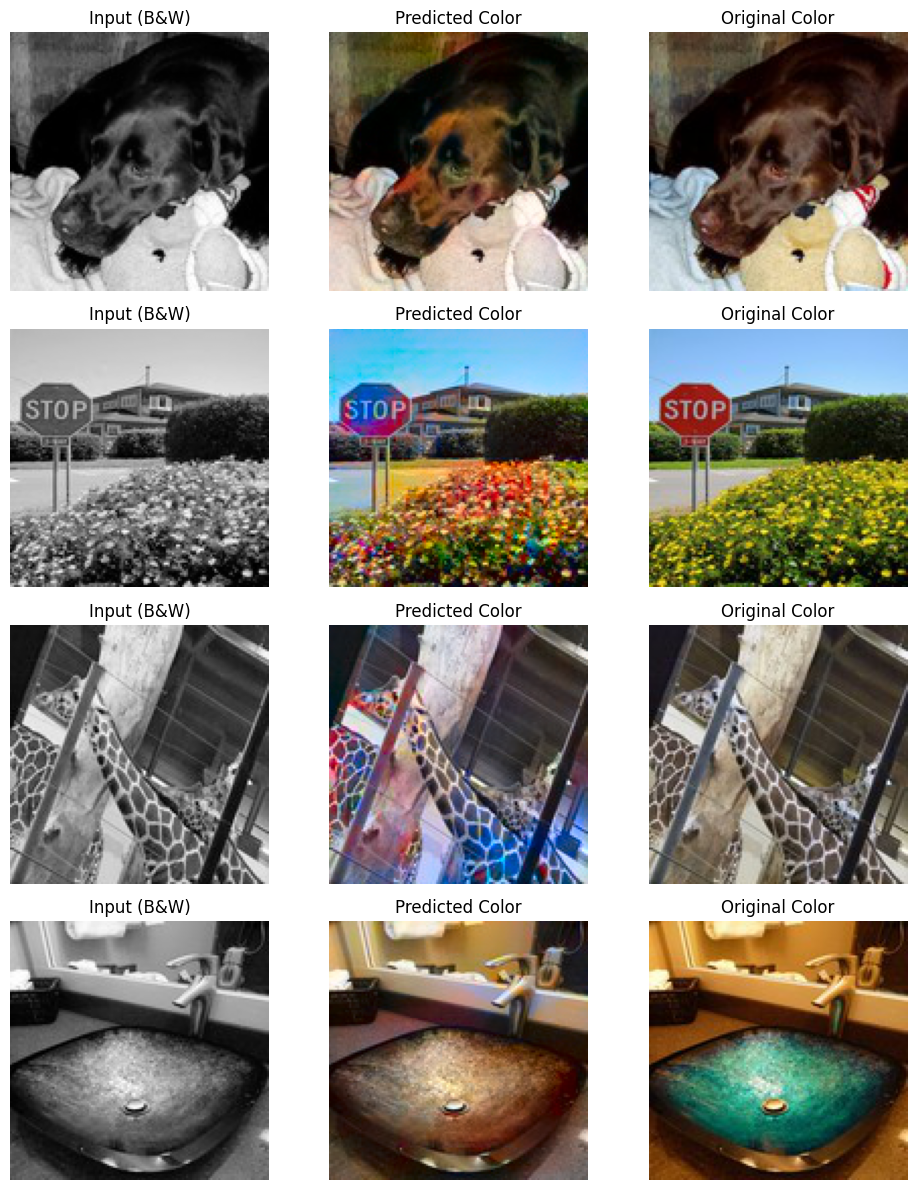

In [11]:
def to_rgb(L, ab):
    """Helper function to convert tensors back to RGB images for plotting."""
    L = L.to("cpu")
    ab = ab.to("cpu")
    
    L = (L + 1.0) * 50.0 
    ab = ab * 110.0      
    
    lab = torch.cat([L, ab], dim=0).detach().numpy()
    lab = lab.transpose((1, 2, 0)) 
    
    rgb = lab2rgb(lab)
    return np.clip(rgb, 0, 1)

model_G.eval()
# Grab a batch of test data
data_iter = iter(test_loader)
L_test, ab_test = next(data_iter)

L_test_gpu = L_test.to(device)
with torch.no_grad():
    ab_pred = model_G(L_test_gpu)

# Plot 4 examples
fig, axes = plt.subplots(4, 3, figsize=(10, 12))
for i in range(4):
    L_img = L_test[i].numpy().transpose(1, 2, 0)
    axes[i, 0].imshow(L_img.squeeze(), cmap='gray')
    axes[i, 0].set_title("Input (B&W)")
    axes[i, 0].axis('off')
    
    pred_rgb = to_rgb(L_test[i], ab_pred[i])
    axes[i, 1].imshow(pred_rgb)
    axes[i, 1].set_title("Predicted Color")
    axes[i, 1].axis('off')
    
    true_rgb = to_rgb(L_test[i], ab_test[i])
    axes[i, 2].imshow(true_rgb)
    axes[i, 2].set_title("Original Color")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()